# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on COVID-19 related datasets.
The objective is to understand the structure, quality, and relationships within the data
before any preprocessing or modelling steps.


In [1]:
# Initialise Spark session for EDA
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when
import matplotlib.pyplot as plt
spark = SparkSession.builder \
    .appName("COVID_EDA") \
    .getOrCreate()


In [2]:
# Load all raw CSV datasets used in the project

caseDF = spark.read.csv("data/Case.csv", header=True, inferSchema=True)
patientDF = spark.read.csv("data/PatientInfo.csv", header=True, inferSchema=True)
policyDF = spark.read.csv("data/Policy.csv", header=True, inferSchema=True)
regionDF = spark.read.csv("data/Region.csv", header=True, inferSchema=True)
searchDF = spark.read.csv("data/SearchTrend.csv", header=True, inferSchema=True)
floatingDF = spark.read.csv("data/SeoulFloating.csv", header=True, inferSchema=True)
timeDF = spark.read.csv("data/Time.csv", header=True, inferSchema=True)
timeAgeDF = spark.read.csv("data/TimeAge.csv", header=True, inferSchema=True)
timeGenderDF = spark.read.csv("data/TimeGender.csv", header=True, inferSchema=True)
timeProvinceDF = spark.read.csv("data/TimeProvince.csv", header=True, inferSchema=True)


In [3]:
# Inspect schema of each dataset to understand column types

timeProvinceDF.printSchema()
regionDF.printSchema()
searchDF.printSchema()
timeGenderDF.printSchema()


root
 |-- date: date (nullable = true)
 |-- time: integer (nullable = true)
 |-- province: string (nullable = true)
 |-- confirmed: integer (nullable = true)
 |-- released: integer (nullable = true)
 |-- deceased: integer (nullable = true)

root
 |-- code: integer (nullable = true)
 |-- province: string (nullable = true)
 |-- city: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- elementary_school_count: integer (nullable = true)
 |-- kindergarten_count: integer (nullable = true)
 |-- university_count: integer (nullable = true)
 |-- academy_ratio: double (nullable = true)
 |-- elderly_population_ratio: double (nullable = true)
 |-- elderly_alone_ratio: double (nullable = true)
 |-- nursing_home_count: integer (nullable = true)

root
 |-- date: date (nullable = true)
 |-- cold: double (nullable = true)
 |-- flu: double (nullable = true)
 |-- pneumonia: double (nullable = true)
 |-- coronavirus: double (nullable = true)

root


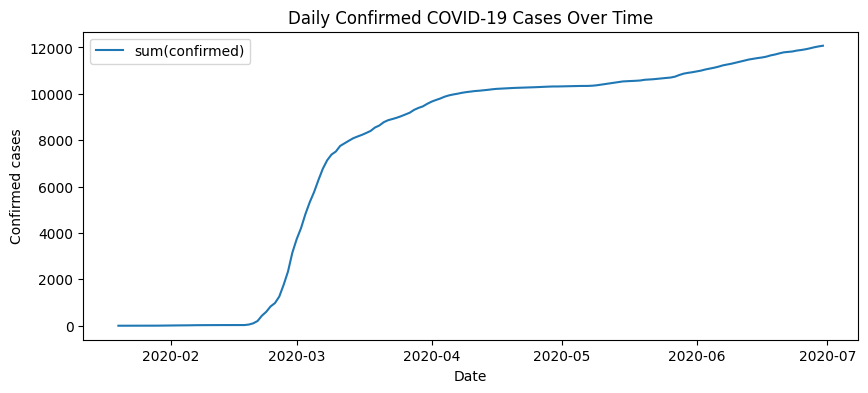

In [4]:
# Time evolution of confirmed cases
# Useful for understanding temporal trends and waves

timeProvinceDF.groupBy("date") \
    .sum("confirmed") \
    .orderBy("date") \
    .toPandas() \
    .plot(
        x="date",
        y="sum(confirmed)",
        figsize=(10, 4)
    )

plt.title("Daily Confirmed COVID-19 Cases Over Time")
plt.ylabel("Confirmed cases")
plt.xlabel("Date")
plt.show()


In [5]:
# Check number of rows in each dataset

print("TimeProvince:", timeProvinceDF.count())
print("Region:", regionDF.count())
print("SearchTrend:", searchDF.count())
print("TimeGender:", timeGenderDF.count())


TimeProvince: 2771
Region: 244
SearchTrend: 1642
TimeGender: 242


In [6]:
# Summary statistics for key numerical columns

timeProvinceDF.select(
    "confirmed", "released", "deceased"
).describe().show()


+-------+------------------+------------------+------------------+
|summary|         confirmed|          released|          deceased|
+-------+------------------+------------------+------------------+
|  count|              2771|              2771|              2771|
|   mean| 444.3081919884518|320.72645254420786| 9.239985564778058|
| stddev|1360.8909633062747|1126.0412546146954|32.638615308276584|
|    min|                 0|                 0|                 0|
|    max|              6906|              6700|               189|
+-------+------------------+------------------+------------------+



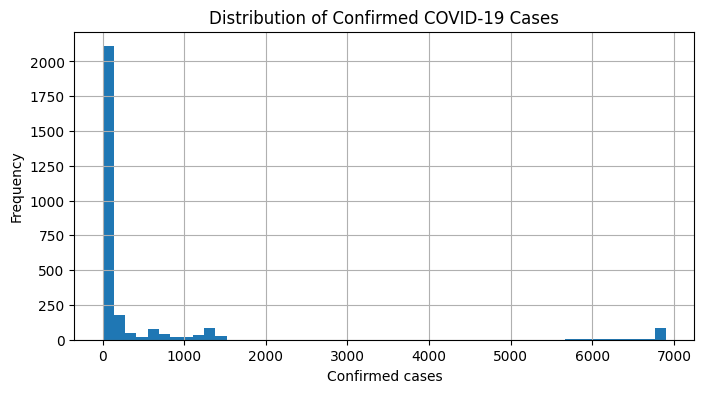

In [7]:
# Distribution of confirmed cases
# This helps understand skewness and justify percentile/median-based label creation



timeProvinceDF.select("confirmed") \
    .toPandas() \
    .hist(bins=50, figsize=(8, 4))

plt.title("Distribution of Confirmed COVID-19 Cases")
plt.xlabel("Confirmed cases")
plt.ylabel("Frequency")
plt.show()


In [8]:
# Percentage of missing values per column in TimeProvince

missing_kpi = timeProvinceDF.select([
    (count(when(col(c).isNull(), c)) / count("*")).alias(c)
    for c in timeProvinceDF.columns
])

missing_kpi.show(truncate=False)


+----+----+--------+---------+--------+--------+
|date|time|province|confirmed|released|deceased|
+----+----+--------+---------+--------+--------+
|0.0 |0.0 |0.0     |0.0      |0.0     |0.0     |
+----+----+--------+---------+--------+--------+



array([[<Axes: title={'center': 'confirmed'}>]], dtype=object)

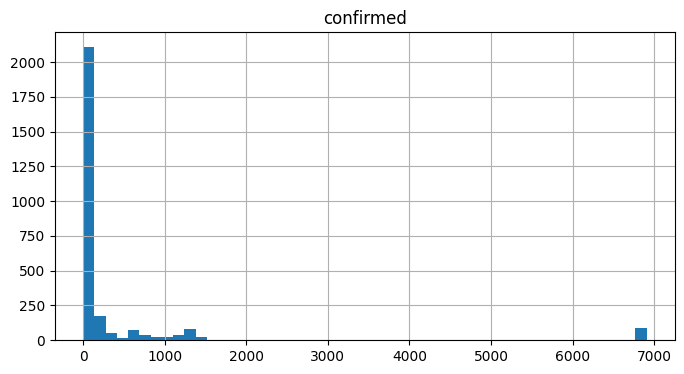

In [9]:
# Distribution of confirmed cases

timeProvinceDF.select("confirmed") \
    .toPandas() \
    .hist(bins=50, figsize=(8, 4))


In [10]:
# Average confirmed cases by province

timeProvinceDF.groupBy("province") \
    .avg("confirmed") \
    .orderBy(col("avg(confirmed)").desc()) \
    .show(truncate=False)


+-----------------+------------------+
|province         |avg(confirmed)    |
+-----------------+------------------+
|Daegu            |4954.0245398773   |
|Gyeongsangbuk-do |988.2147239263803 |
|Seoul            |502.5950920245399 |
|Gyeonggi-do      |497.29447852760734|
|Chungcheongnam-do|102.94478527607362|
|Incheon          |102.11656441717791|
|Busan            |100.25153374233129|
|Gyeongsangnam-do |85.03067484662577 |
|Gangwon-do       |36.24539877300614 |
|Chungcheongbuk-do|35.58895705521472 |
|Ulsan            |32.32515337423313 |
|Daejeon          |32.00613496932515 |
|Sejong           |31.355828220858896|
|Gwangju          |20.607361963190183|
|Jeollabuk-do     |12.932515337423313|
|Jeollanam-do     |10.815950920245399|
|Jeju-do          |8.889570552147239 |
+-----------------+------------------+



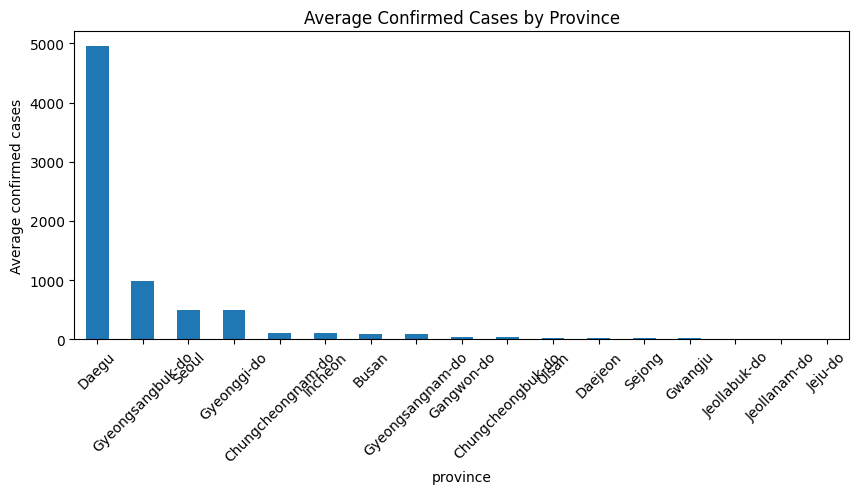

In [11]:
# Average confirmed cases per province
# Shows strong regional patterns

avg_province = (
    timeProvinceDF.groupBy("province")
    .avg("confirmed")
    .orderBy(col("avg(confirmed)").desc())
    .toPandas()
)

avg_province.plot(
    kind="bar",
    x="province",
    y="avg(confirmed)",
    figsize=(10, 4),
    legend=False
)

plt.title("Average Confirmed Cases by Province")
plt.ylabel("Average confirmed cases")
plt.xticks(rotation=45)
plt.show()


<Axes: xlabel='date'>

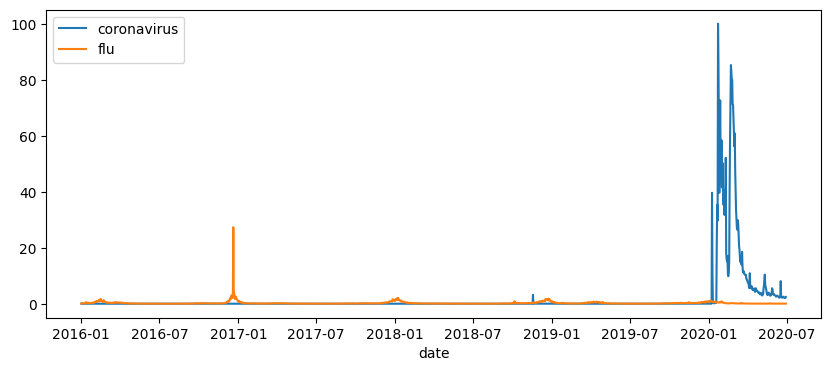

In [12]:
# Relationship between search trends and confirmed cases

searchDF.select(
    "date", "coronavirus", "flu"
).toPandas().plot(
    x="date",
    y=["coronavirus", "flu"],
    figsize=(10, 4)
)


In [13]:
# Summary of regional demographic indicators

regionDF.select(
    "academy_ratio",
    "elderly_population_ratio",
    "elderly_alone_ratio",
    "nursing_home_count"
).describe().show()


+-------+------------------+------------------------+-------------------+------------------+
|summary|     academy_ratio|elderly_population_ratio|elderly_alone_ratio|nursing_home_count|
+-------+------------------+------------------------+-------------------+------------------+
|  count|               244|                     244|                244|               244|
|   mean|1.2947540983606531|      20.923729508196736| 10.644672131147537|1159.2581967213114|
| stddev|0.5928979025284541|       8.087427906866017|  5.604885829305476| 6384.185084757067|
|    min|              0.19|                    7.69|                3.3|                11|
|    max|              4.18|                   40.26|               24.7|             94865|
+-------+------------------+------------------------+-------------------+------------------+



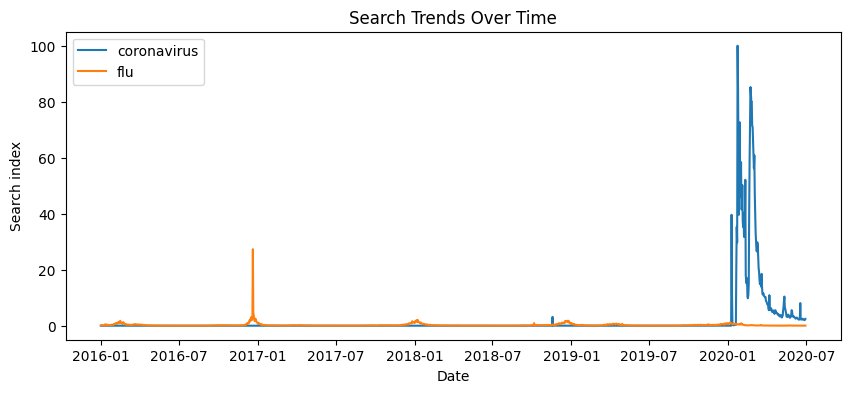

In [14]:
# Search trends related to COVID-19
# Behavioural indicators often precede case increases

searchDF.select("date", "coronavirus", "flu") \
    .orderBy("date") \
    .toPandas() \
    .plot(
        x="date",
        y=["coronavirus", "flu"],
        figsize=(10, 4)
    )

plt.title("Search Trends Over Time")
plt.ylabel("Search index")
plt.xlabel("Date")
plt.show()


<Axes: >

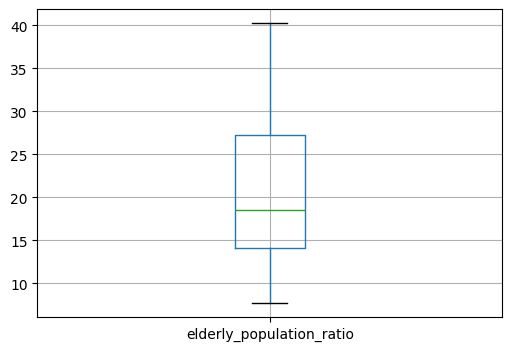

In [15]:
# Boxplot to inspect potential outliers in elderly population ratio

regionDF.select("elderly_population_ratio") \
    .toPandas() \
    .boxplot(figsize=(6, 4))


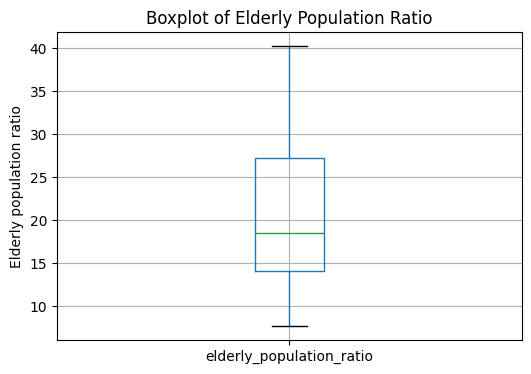

In [16]:
# Boxplot for elderly population ratio
# Used to inspect potential outliers before preprocessing

regionDF.select("elderly_population_ratio") \
    .toPandas() \
    .boxplot(figsize=(6, 4))

plt.title("Boxplot of Elderly Population Ratio")
plt.ylabel("Elderly population ratio")
plt.show()


In [17]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# Assemble numerical features for correlation analysis
corr_assembler = VectorAssembler(
    inputCols=["confirmed", "released", "deceased"],
    outputCol="corr_features"
)

corr_df = corr_assembler.transform(timeProvinceDF) \
    .select("corr_features")

Correlation.corr(corr_df, "corr_features").show()




+----------------------+
|pearson(corr_features)|
+----------------------+
|  1.0              ...|
+----------------------+



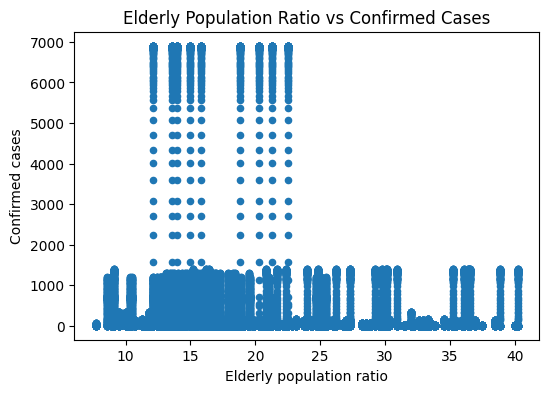

In [18]:
# Relationship between elderly population ratio and confirmed cases
# Helps understand demographic risk factors

merged_for_plot = timeProvinceDF.join(
    regionDF, on="province", how="left"
)

merged_for_plot.select(
    "elderly_population_ratio", "confirmed"
).toPandas().plot(
    kind="scatter",
    x="elderly_population_ratio",
    y="confirmed",
    figsize=(6, 4)
)

plt.title("Elderly Population Ratio vs Confirmed Cases")
plt.xlabel("Elderly population ratio")
plt.ylabel("Confirmed cases")
plt.show()


### Visual Analysis Summary

The exploratory visual analysis reveals strong temporal and regional patterns in COVID-19
confirmed cases. Demographic indicators such as elderly population ratio show meaningful
relationships with case counts. Behavioural indicators, captured through search trends,
exhibit temporal alignment with epidemic waves. These observations motivate the selected
features and the use of a time-based train–test split in subsequent modelling.


In [19]:
# Convert correlation matrix to readable format
import pandas as pd
corr_matrix = Correlation.corr(corr_df, "corr_features").head()[0]
print(corr_matrix)

pd.DataFrame(
    corr_matrix.toArray(),
    columns=["confirmed", "released", "deceased"],
    index=["confirmed", "released", "deceased"]
)


DenseMatrix([[1.        , 0.93329513, 0.94979511],
             [0.93329513, 1.        , 0.98720747],
             [0.94979511, 0.98720747, 1.        ]])


,confirmed,released,deceased
confirmed,1.000000,0.933295,0.949795
released,0.933295,1.000000,0.987207
deceased,0.949795,0.987207,1.000000


## EDA Summary

- Confirmed cases exhibit a highly skewed distribution.
- Strong regional patterns are observed across provinces.
- Search trends show temporal alignment with case increases.
- Demographic and regional indicators vary significantly and are expected to be useful features.
- Missing values are present and will be handled during preprocessing.

These insights guide feature selection and modelling choices in the next notebook.
